In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.dates as mdates

df=pd.read_csv('Data_HW2.csv')
print(df)

              Sample Type             Date  Ca_ueq_L  DOC_mg_L  Flow_cfs
0          W9 stream  mix  3/19/1996 11:50     946.2      1.04   0.27366
1          W9 stream  mix  3/26/1996 11:40     830.9      2.05   0.53274
2          W9 stream  mix  3/26/1996 11:40     894.3      1.41   0.53274
3          W9 stream  mix   4/1/1996 18:30     773.5      2.06   0.80191
4          W9 stream  mix   4/2/1996 11:05     876.3      1.51   0.57686
..               ...  ...              ...       ...       ...       ...
84  Overland flow W9  em2  4/25/1996 18:07       NaN      1.43       NaN
85  Overland flow W9  em2  4/26/1996 18:30       NaN       NaN       NaN
86  Overland flow W9  em2  4/26/1996 18:36       NaN       NaN       NaN
87  Overland flow W9  em2  4/26/1996 18:55       NaN       NaN       NaN
88  Overland flow W9  em2   5/9/1996 13:05       NaN       NaN       NaN

[89 rows x 6 columns]


In [2]:
df['Date']=pd.to_datetime(df['Date'])
print(df)

              Sample Type                Date  Ca_ueq_L  DOC_mg_L  Flow_cfs
0          W9 stream  mix 1996-03-19 11:50:00     946.2      1.04   0.27366
1          W9 stream  mix 1996-03-26 11:40:00     830.9      2.05   0.53274
2          W9 stream  mix 1996-03-26 11:40:00     894.3      1.41   0.53274
3          W9 stream  mix 1996-04-01 18:30:00     773.5      2.06   0.80191
4          W9 stream  mix 1996-04-02 11:05:00     876.3      1.51   0.57686
..               ...  ...                 ...       ...       ...       ...
84  Overland flow W9  em2 1996-04-25 18:07:00       NaN      1.43       NaN
85  Overland flow W9  em2 1996-04-26 18:30:00       NaN       NaN       NaN
86  Overland flow W9  em2 1996-04-26 18:36:00       NaN       NaN       NaN
87  Overland flow W9  em2 1996-04-26 18:55:00       NaN       NaN       NaN
88  Overland flow W9  em2 1996-05-09 13:05:00       NaN       NaN       NaN

[89 rows x 6 columns]


In [3]:
em2_Ca_av=df.loc[df['Type']=='em2', 'Ca_ueq_L'].mean()
em2_DOC_av=df.loc[df['Type']=='em2', 'DOC_mg_L'].mean()
em1_Ca_av=df.loc[df['Type']=='em1', 'Ca_ueq_L'].mean()
em1_DOC_av=df.loc[df['Type']=='em1', 'DOC_mg_L'].mean()
print(f'em2 Ca average: {em2_Ca_av} ueq/L')
print(f'em2 DOC average: {em2_DOC_av} mg/L')
print(f'em1 Ca average: {em1_Ca_av} ueq/L')
print(f'em1 DOC average: {em1_DOC_av} mg/L')

em2 Ca average: 282.72222222222223 ueq/L
em2 DOC average: 3.3 mg/L
em1 Ca average: 1030.7875 ueq/L
em1 DOC average: 1.02 mg/L


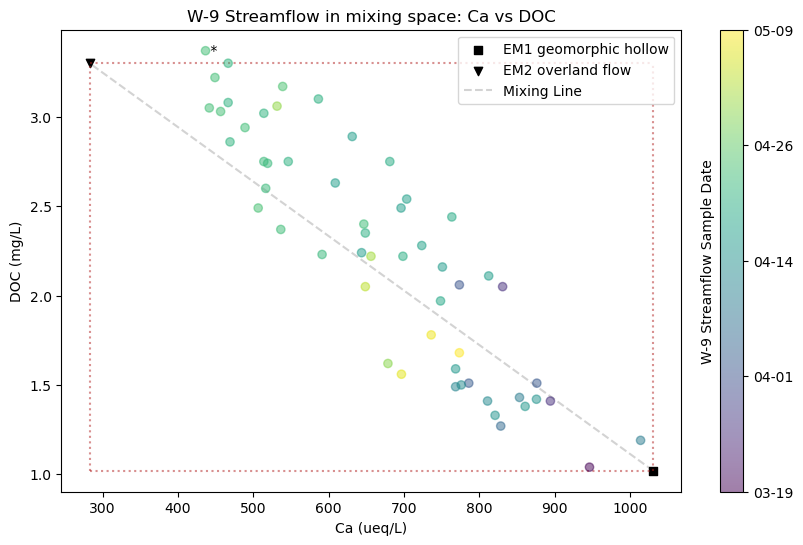

In [49]:
fig, ax = plt.subplots(figsize=(10,6))

date_num=mdates.date2num(df.loc[df['Type']=='mix', 'Date'])
ticks=np.linspace(date_num.min(), date_num.max(), num=5)

sc=ax.scatter(df.loc[df['Type']=='mix', 'Ca_ueq_L'], df.loc[df['Type']=='mix', 'DOC_mg_L'], c=date_num, cmap='viridis', alpha=0.5, zorder=1000)
ax.scatter(em1_Ca_av, em1_DOC_av, color='black', marker='s', label='EM1 geomorphic hollow')
ax.scatter(em2_Ca_av, em2_DOC_av, color='black',marker='v', label='EM2 overland flow')
ax.plot([em1_Ca_av, em2_Ca_av], [em1_DOC_av, em2_DOC_av], color='lightgray', linestyle='--', label='Mixing Line', zorder=-1000)
cbar=plt.colorbar(sc, ax=ax)
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
cbar.set_label('W-9 Streamflow Sample Date')
cbar.ax.yaxis.set_label_position('left')

#I want an asterix to label that one point that is clearly higher in DOC than end members.
row=df.loc[(df['Type']=='mix') & (df['Date'].dt.strftime('%m-%d')=='04-23')].iloc[5]

ax.text(row['Ca_ueq_L'], row['DOC_mg_L'],' *', color='black', fontsize=10, va='center', ha='left')

#I want a box around my mixing space so it's really easy to see the single outlier.
x_min = min(em1_Ca_av, em2_Ca_av)
x_max = max(em1_Ca_av, em2_Ca_av)
y_min = min(em1_DOC_av, em2_DOC_av)
y_max = max(em1_DOC_av, em2_DOC_av)
ax.vlines([x_min, x_max],ymin=y_min,ymax=y_max,colors='firebrick',linestyles=':',alpha=0.5)
ax.hlines([y_min, y_max],xmin=x_min,xmax=x_max,colors='firebrick',linestyles=':',alpha=0.5)


ax.set_xlabel('Ca (ueq/L)')
ax.set_ylabel('DOC (mg/L)')
ax.set_title('W-9 Streamflow in mixing space: Ca vs DOC')
ax.legend(loc='upper right')
plt.show()

In [5]:
#Mixing model using Ca as the conservative tracer
df_mix=df.loc[df['Type']=='mix'].copy()

df_mix['Flow_cfs_em1_Ca']=df_mix['Flow_cfs']*(df_mix['Ca_ueq_L']-em2_Ca_av)/(em1_Ca_av-em2_Ca_av)
df_mix['Flow_cfs_em2_Ca']=df_mix['Flow_cfs']*(df_mix['Ca_ueq_L']-em1_Ca_av)/(em2_Ca_av-em1_Ca_av)

#Mixing model using DOC as the conservative tracer
df_mix['Flow_cfs_em1_DOC']=df_mix['Flow_cfs']*(df_mix['DOC_mg_L']-em2_DOC_av)/(em1_DOC_av-em2_DOC_av)
df_mix['Flow_cfs_em2_DOC']=df_mix['Flow_cfs']*(df_mix['DOC_mg_L']-em1_DOC_av)/(em2_DOC_av-em1_DOC_av)

print(df_mix)

       Sample Type                Date  Ca_ueq_L  DOC_mg_L  Flow_cfs  \
0   W9 stream  mix 1996-03-19 11:50:00     946.2      1.04   0.27366   
1   W9 stream  mix 1996-03-26 11:40:00     830.9      2.05   0.53274   
2   W9 stream  mix 1996-03-26 11:40:00     894.3      1.41   0.53274   
3   W9 stream  mix 1996-04-01 18:30:00     773.5      2.06   0.80191   
4   W9 stream  mix 1996-04-02 11:05:00     876.3      1.51   0.57686   
5   W9 stream  mix 1996-04-02 17:10:00     786.0      1.51   0.64162   
6   W9 stream  mix 1996-04-05 12:45:00     828.4      1.27   0.44547   
7   W9 stream  mix 1996-04-09 13:30:00     853.3      1.43   0.39839   
8   W9 stream  mix 1996-04-09 13:30:00    1014.0      1.19   0.39839   
9   W9 stream  mix 1996-04-11 16:23:00     768.5      1.49   0.68169   
10  W9 stream  mix 1996-04-12 09:45:00     810.9      1.41   0.55752   
11  W9 stream  mix 1996-04-12 17:59:00     776.0      1.50   0.64813   
12  W9 stream  mix 1996-04-14 09:10:00     820.9      1.33   0.5

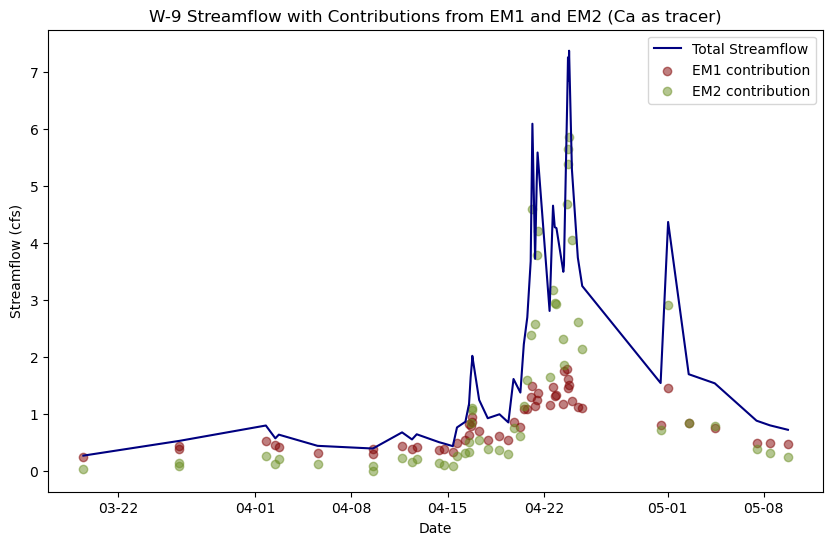

In [6]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(df_mix['Date'], df_mix['Flow_cfs'], color='navy', label='Total Streamflow')
ax.scatter(df_mix['Date'], df_mix['Flow_cfs_em1_Ca'], color='maroon', label='EM1 contribution', alpha=0.5)
ax.scatter(df_mix['Date'], df_mix['Flow_cfs_em2_Ca'], color='olivedrab', label='EM2 contribution', alpha=0.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.set_xlabel('Date')
ax.set_ylabel('Streamflow (cfs)')
ax.set_title('W-9 Streamflow with Contributions from EM1 and EM2 (Ca as tracer)')
ax.legend()
plt.show()

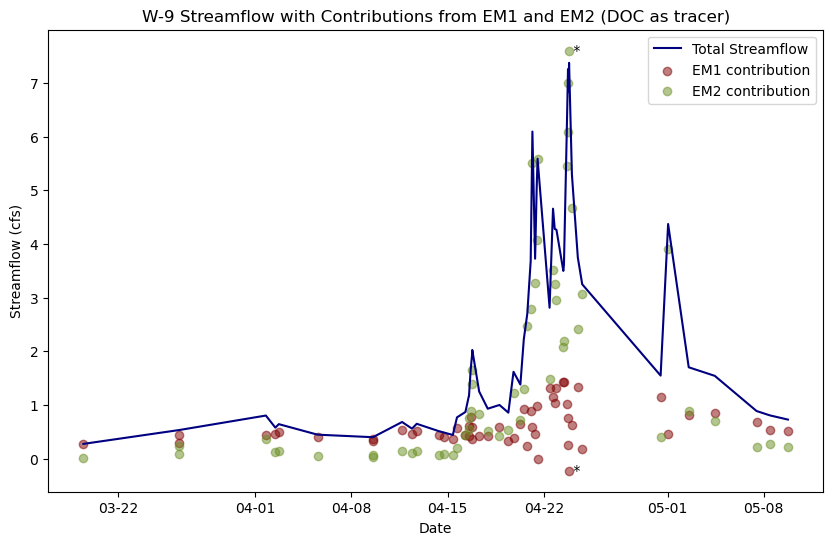

In [25]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(df_mix['Date'], df_mix['Flow_cfs'], color='navy', label='Total Streamflow')
ax.scatter(df_mix['Date'], df_mix['Flow_cfs_em1_DOC'], color='maroon', label='EM1 contribution', alpha=0.5)
ax.scatter(df_mix['Date'], df_mix['Flow_cfs_em2_DOC'], color='olivedrab', label='EM2 contribution', alpha=0.5)
# Get the flagged row
row = df_mix.loc[df_mix['Date'].dt.strftime('%m-%d') == '04-23'].iloc[5]

# EM1 asterisk
ax.text(
    row['Date'],
    row['Flow_cfs_em1_DOC'],
    ' *',
    color='black',
    fontsize=10,
    va='center', ha='left'
)

# EM2 asterisk
ax.text(
    row['Date'],
    row['Flow_cfs_em2_DOC'],
    ' *',
    color='black',
    fontsize=10,
    va='center', ha='left'
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.set_xlabel('Date')
ax.set_ylabel('Streamflow (cfs)')
ax.set_title('W-9 Streamflow with Contributions from EM1 and EM2 (DOC as tracer)')
ax.legend()
plt.show()

In [ ]:
#I want a way to visualize the differences between the two tracers in terms of estimated contributions

#Ca proportions
df_mix['em1_frac_Ca']=df_mix['Flow_cfs_em1_Ca']/df_mix['Flow_cfs']
df_mix['em2_frac_Ca']=df_mix['Flow_cfs_em2_Ca']/df_mix['Flow_cfs']

#DOC proportions
df_mix['em1_frac_DOC']=df_mix['Flow_cfs_em1_DOC']/df_mix['Flow_cfs']
df_mix['em2_frac_DOC']=df_mix['Flow_cfs_em2_DOC']/df_mix['Flow_cfs']

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(df_mix['Date'], df_mix['em1_frac_Ca'], label='EM1 (Ca)', color='maroon')
ax.plot(df_mix['Date'], df_mix['em1_frac_DOC'], label='EM1 (DOC)', color='maroon', linestyle='--')

#ax.plot(df_mix['Date'], df_mix['em2_frac_Ca'], label='EM2 (Ca)', color='olivedrab')
#ax.plot(df_mix['Date'], df_mix['em2_frac_DOC'], label='EM2 (DOC)', color='olivedrab', linestyle='--')

ax.set_ylabel('Fraction of Streamflow')
ax.set_xlabel('Date')
ax.set_title('Geomorphic Hollow EM1 Contributions: Ca vs DOC Mixing Models')

ax.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.plot(df_mix['Date'], df_mix['em2_frac_Ca'], label='EM2 (Ca)', color='olivedrab')
ax.plot(df_mix['Date'], df_mix['em2_frac_DOC'], label='EM2 (DOC)', color='olivedrab', linestyle='--')

ax.set_ylabel('Fraction of Streamflow')
ax.set_xlabel('Date')
ax.set_title('Overland Flow EM2 Contributions: Ca vs DOC Mixing Models')

ax.legend()
plt.show()

In [ ]:
df_mix['em1_diff'] = df_mix['em1_frac_Ca'] - df_mix['em1_frac_DOC']
df_mix['em2_diff'] = df_mix['em2_frac_Ca'] - df_mix['em2_frac_DOC']

fig, ax = plt.subplots(figsize=(10,6))

ax2 = ax.twinx()

ax2.plot(df_mix['Date'], df_mix['Flow_cfs'],color='navy', alpha=0.5, label='Streamflow')

ax.axhline(0, color='gray', linestyle='--')

ax.scatter(df_mix['Date'], df_mix['em1_diff'], label='EM1 (Ca - DOC)', color='maroon', alpha=0.5)
ax.scatter(df_mix['Date'], df_mix['em2_diff'], label='EM2 (Ca - DOC)', color='olivedrab', alpha=0.5)

ax.set_ylabel('Difference in Fraction')
ax2.set_ylabel('Streamflow (cfs)')
ax.set_title('Difference Between Mixing Models')

ax.legend()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))

ax.scatter(df_mix['em1_frac_Ca'], df_mix['em1_frac_DOC'], color='maroon', label='EM1',alpha=0.5)
ax.scatter(df_mix['em2_frac_Ca'], df_mix['em2_frac_DOC'], color='olivedrab', label='EM2',alpha=0.5)

# 1:1 line
x = np.linspace(0,1,100)
ax.plot(x, x, linestyle='--', color='gray', label='tracer agreement')

ax.set_xlabel('Relative contribution with Ca as tracer')
ax.set_ylabel('Relative contribution with DOC as tracer')
ax.set_title('Mixing Model Tracer Comparison')

ax.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

fig, ax = plt.subplots(figsize=(10,6))

# Scatter plots
ax.scatter(df_mix['em1_frac_Ca'], df_mix['em1_frac_DOC'], color='maroon', label='EM1', alpha=0.5)
ax.scatter(df_mix['em2_frac_Ca'], df_mix['em2_frac_DOC'], color='olivedrab', label='EM2', alpha=0.5)

# 1:1 line
x = np.linspace(0,1,100)
ax.plot(x, x, linestyle='--', color='gray', label='tracer agreement')

# Combine both datasets for R²
y_true = np.concatenate([df_mix['em1_frac_DOC'], df_mix['em2_frac_DOC']])
y_pred = np.concatenate([df_mix['em1_frac_Ca'], df_mix['em2_frac_Ca']])

r2 = r2_score(y_true, y_pred)
print(f"Combined R²: {r2:.3f}")

# Optionally, display R² on the plot
ax.text(0.75, 0.68, f'$R^2 = {r2:.3f}$', transform=ax.transAxes,
        fontsize=12, verticalalignment='top')

ax.set_xlabel('Relative contribution with Ca as tracer')
ax.set_ylabel('Relative contribution with DOC as tracer')
ax.set_title('Mixing Model Tracer Comparison')
ax.legend(loc='upper left')
plt.show()

In [ ]:
# I want to look at normalized differences so I can get away from some of the different flow dynamics affecting the absolute differences

df_mix['NDI_em1']=(df_mix['Flow_cfs_em1_Ca'] - df_mix['Flow_cfs_em1_DOC']) / (df_mix['Flow_cfs_em1_Ca'] + df_mix['Flow_cfs_em1_DOC'])
df_mix['NDI_em2']=(df_mix['Flow_cfs_em2_Ca'] - df_mix['Flow_cfs_em2_DOC']) / (df_mix['Flow_cfs_em2_Ca'] + df_mix['Flow_cfs_em2_DOC'])

fig, ax = plt.subplots(figsize=(10,6))

ax2 = ax.twinx()

ax.scatter(df_mix['Date'], df_mix['NDI_em1'], label='EM1 NDI', color='maroon', alpha=0.5)
ax.scatter(df_mix['Date'], df_mix['NDI_em2'], label='EM2 NDI', color='olivedrab', alpha=0.5)
ax2.plot(df_mix['Date'], df_mix['Flow_cfs'], color='navy', alpha=0.5, label='Streamflow')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Difference Index')
ax2.set_ylabel('Streamflow (cfs)')
ax.set_title('Normalized Difference Index Between Tracers')
ax.legend()
plt.show()

In [ ]:
df_mix.to_csv('df_mix_NDI_debug.csv', index=False)